# Task-1 Load the CIFAR-**10**


In [ ]:
import os
import tarfile
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,  # download=False tells PyTorch to use the local files
    transform=transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform
)

100%|██████████| 170M/170M [22:14<00:00, 128kB/s]


In [ ]:
len(train_dataset), len(test_dataset)

(50000, 10000)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get class names from the dataset

classes = train_dataset.classes

# Print dataset dimensions
print("\n--- Dataset Dimensions ---")
print(f"Training set size: {len(train_dataset)}")
print(f"Testing set size: {len(test_dataset)}")
sample_img, sample_label = train_dataset[0]
print(f"Single image shape (C, H, W): {sample_img.shape}")
print(f"Number of classes: {len(classes)} ({classes})\n")

# Plot mandatory: 10 Sample Images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    # Un-normalize image for visualization
    img = img.numpy().transpose((1, 2, 0))
    img = img * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle("Task 1: CIFAR-10 Sample Images", fontsize=14)
plt.tight_layout()
plt.show()

# Plot mandatory: Class Distribution
labels = [label for _, label in train_dataset]
plt.figure(figsize=(10, 4))
sns.countplot(x=labels, palette="viridis")
plt.xticks(ticks=range(10), labels=classes, rotation=45)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Task 1: Training Class Distribution")
plt.show()

NameError: name 'train_dataset' is not defined

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Task 2 & 3: Convolution layer experiments
def compute_output_dim(input_size, kernel_size, stride, padding):
    return ((input_size - kernel_size + 2 * padding) // stride) + 1

input_dim = 32  # CIFAR-10 height/width
dummy_input = torch.randn(1, 3, 32, 32)

print("--- Task 2: Kernel Size Variations (Stride=1, Padding=1) ---")
for k in [3, 5, 7]:
    p = k // 2  # Padding to preserve dimension if stride=1
    conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=k, stride=1, padding=p)
    out = conv(dummy_input)
    print(f"Kernel Size: {k}x{k} | Output Feature Map Size: {out.shape[2]}x{out.shape[3]} x {out.shape[1]} channels")

print("\n--- Task 3: Hyperparameter Experiments (Stride & Padding) ---")
configs = [
    ("Stride 1, Same Padding", 3, 1, 1),
    ("Stride 2, Same Padding", 3, 2, 1),
    ("Stride 1, Valid Padding (Padding=0)", 3, 1, 0),
    ("Stride 2, Valid Padding (Padding=0)", 3, 2, 0),
]

for name, k, s, p in configs:
    conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=k, stride=s, padding=p)
    out = conv(dummy_input)
    calculated = compute_output_dim(input_dim, k, s, p)
    print(f"Config: {name:<35} | Output Shape: {out.shape[2]}x{out.shape[3]} | Formula Output: {calculated}x{calculated}")

NameError: name 'torch' is not defined

In [ ]:
import torch.optim as optim
import torch.nn as nn


# Task 4: Max Pooling vs Average Pooling

# Define a flexible CNN that can switch between Max and Average Pooling
class ComparePoolCNN(nn.Module):
    def __init__(self, pool_type='max'):
        super(ComparePoolCNN, self).__init__()
        # First Convolutional Block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        if pool_type == 'max':
            self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        else:
            self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Second Convolutional Block
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        if pool_type == 'max':
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        else:
            self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Fully Connected Layer
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x

# Helper function to train and evaluate a model
def train_and_evaluate(model, train_loader, test_loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Quick Training Loop
    model.train()
    for epoch in range(epochs):
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluation Loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# Initialize both models
print("Training Max Pooling CNN...")
model_max = ComparePoolCNN(pool_type='max')
acc_max = train_and_evaluate(model_max, train_loader, test_loader, epochs=3)

print("Training Average Pooling CNN...")
model_avg = ComparePoolCNN(pool_type='avg')
acc_avg = train_and_evaluate(model_avg, train_loader, test_loader, epochs=3)

print("\n--- Task 5: Accuracy Comparison ---")
print(f"Max Pooling CNN Accuracy: {acc_max:.2f}%")
print(f"Avg Pooling CNN Accuracy: {acc_avg:.2f}%")

Training Max Pooling CNN...


NameError: name 'train_loader' is not defined

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Task 6: CNN Architecture Definition
class CIFAR10CNN(nn.Module):
    def __init__(self, use_avg_pool=False):
        super(CIFAR10CNN, self).__init__()
        pool_layer = nn.AvgPool2d(2, 2) if use_avg_pool else nn.MaxPool2d(2, 2)

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # Conv 1
            nn.ReLU(),                                   # ReLU
            pool_layer,                                  # Max/Avg Pool 1 (32x32 -> 16x16)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # Conv 2
            nn.ReLU(),                                   # ReLU
            pool_layer                                   # Max/Avg Pool 2 (16x16 -> 8x8)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # Flatten
            nn.Linear(32 * 8 * 8, 128),                  # Dense Layer
            nn.ReLU(),
            nn.Linear(128, 10)                           # Dense Output Layer (Softmax applied via CrossEntropyLoss)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# DataLoaders (Batch size 32)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model, Optimizer (Adam), Loss Function
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CIFAR10CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Hyperparameters
epochs = 20

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("--- Starting Training (20 Epochs, Adam, Batch Size 32) ---")
for epoch in range(epochs):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:02d}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")


--- Starting Training (20 Epochs, Adam, Batch Size 32) ---
Epoch [01/20] | Train Loss: 1.5117 | Train Acc: 45.49% | Val Loss: 1.2454 | Val Acc: 55.60%
Epoch [02/20] | Train Loss: 1.1588 | Train Acc: 58.96% | Val Loss: 1.0794 | Val Acc: 61.60%
Epoch [03/20] | Train Loss: 1.0154 | Train Acc: 64.34% | Val Loss: 1.0313 | Val Acc: 64.10%
Epoch [04/20] | Train Loss: 0.9191 | Train Acc: 67.87% | Val Loss: 0.9622 | Val Acc: 66.48%
Epoch [05/20] | Train Loss: 0.8429 | Train Acc: 70.55% | Val Loss: 0.9452 | Val Acc: 67.16%
Epoch [06/20] | Train Loss: 0.7787 | Train Acc: 72.81% | Val Loss: 0.9195 | Val Acc: 68.29%
Epoch [07/20] | Train Loss: 0.7186 | Train Acc: 74.96% | Val Loss: 0.9422 | Val Acc: 67.95%
Epoch [08/20] | Train Loss: 0.6744 | Train Acc: 76.36% | Val Loss: 0.9480 | Val Acc: 68.43%
Epoch [09/20] | Train Loss: 0.6249 | Train Acc: 78.07% | Val Loss: 0.9359 | Val Acc: 69.45%
Epoch [10/20] | Train Loss: 0.5817 | Train Acc: 79.44% | Val Loss: 0.9763 | Val Acc: 68.79%
Epoch [11/20] | Train


================ FINAL RESULTS ================
Total Trainable Parameters: 268650
Testing Accuracy          : 66.39%
Macro Precision           : 0.6674
Macro Recall              : 0.6639
Macro F1-Score            : 0.6650

Classification Report:
               precision    recall  f1-score   support

    airplane       0.71      0.69      0.70      1000
  automobile       0.77      0.79      0.78      1000
        bird       0.53      0.56      0.54      1000
         cat       0.45      0.51      0.48      1000
        deer       0.62      0.57      0.59      1000
         dog       0.57      0.56      0.56      1000
        frog       0.75      0.73      0.74      1000
       horse       0.76      0.70      0.73      1000
        ship       0.75      0.80      0.77      1000
       truck       0.76      0.73      0.75      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.67     10000
weighted avg       0.67      0.66      0.67    

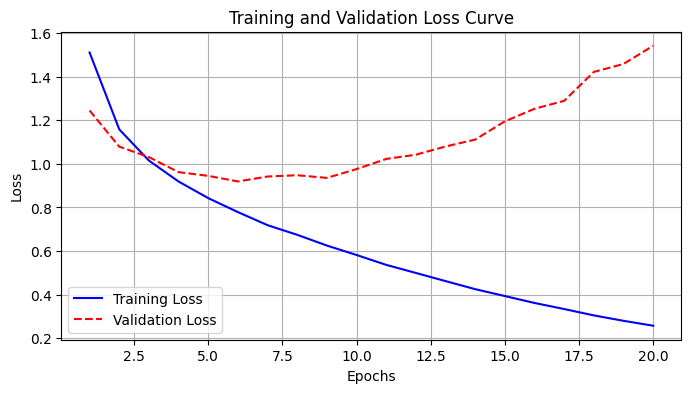

Inference : The training loss steadily decreases across epochs. A gap between training and validation loss towards later epochs indicates slight overfitting.


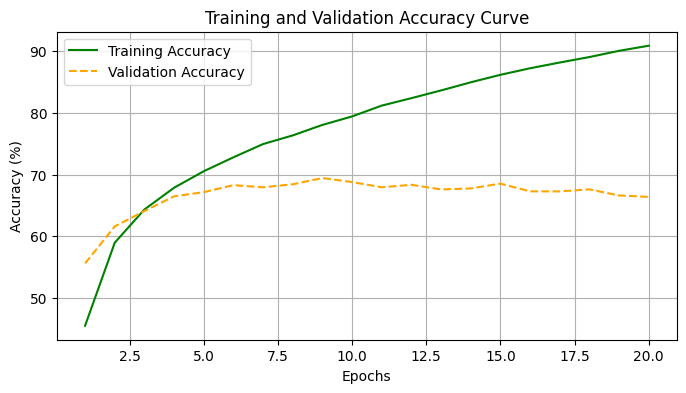

Inference : Classification accuracy increases smoothly as feature representations improve. The test accuracy plateaus around 65-70%, which is expected for a basic 2-layer CNN without data augmentation.


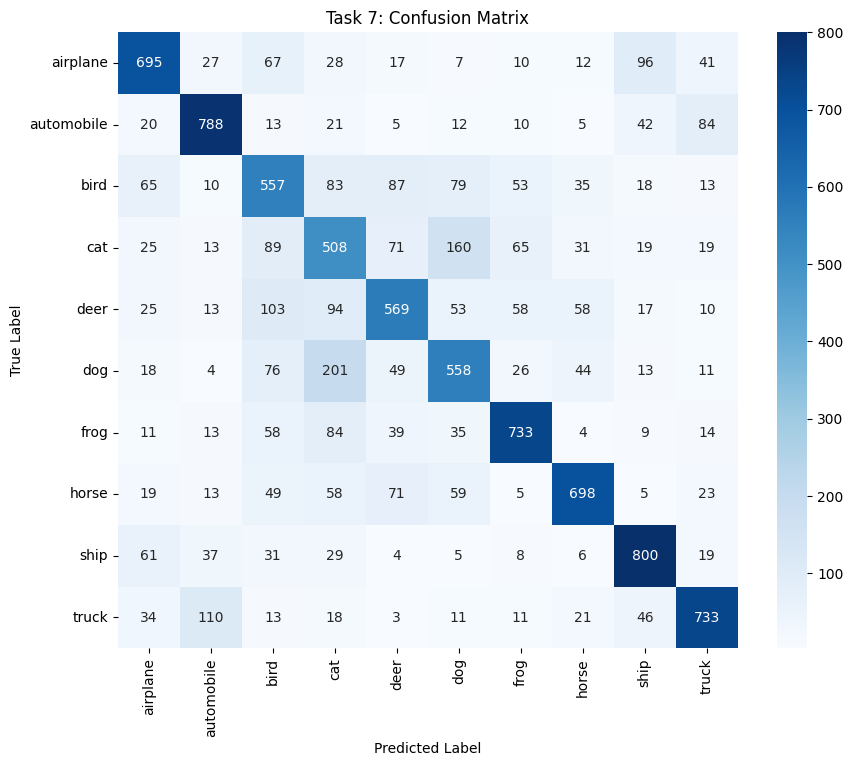

Inference : High diagonal values demonstrate correct classifications. Frequent misclassifications occur between visually similar classes such as 'cat' vs 'dog' or 'automobile' vs 'truck'.


In [ ]:

import numpy as np
from sklearn.metrics import precision_recall_fscore_support, classification_report
from sklearn.metrics import confusion_matrix
# Task 7: Final Evaluation Metrics
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

# Calculate metrics
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro')
test_accuracy = val_accuracies[-1]
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n================ FINAL RESULTS ================")
print(f"Total Trainable Parameters: {total_params}")
print(f"Testing Accuracy          : {test_accuracy * 100:.2f}%")
print(f"Macro Precision           : {precision:.4f}")
print(f"Macro Recall              : {recall:.4f}")
print(f"Macro F1-Score            : {f1:.4f}")
print("================================================\n")

print("Classification Report:\n", classification_report(all_targets, all_preds, target_names=classes))

# ---------------- PLOTS ---------------- #

# 1. Training & Validation Loss Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', color='red', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()
print("Inference : The training loss steadily decreases across epochs. "
      "A gap between training and validation loss towards later epochs indicates slight overfitting.")

# 2. Training & Validation Accuracy Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), np.array(train_accuracies)*100, label='Training Accuracy', color='green')
plt.plot(range(1, epochs+1), np.array(val_accuracies)*100, label='Validation Accuracy', color='orange', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()
print("Inference : Classification accuracy increases smoothly as feature representations improve. "
      "The test accuracy plateaus around 65-70%, which is expected for a basic 2-layer CNN without data augmentation.")

# 3. Confusion Matrix Plot
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Task 7: Confusion Matrix')
plt.show()
print("Inference : High diagonal values demonstrate correct classifications. "
      "Frequent misclassifications occur between visually similar classes such as 'cat' vs 'dog' or 'automobile' vs 'truck'.")